In [1]:
# GEREKLİ KÜTÜPHANELERİN İMPORT EDİLMESİ
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# VERİ SETİNİN OKUNMASI
df = pd.read_csv('marketing_campaign.csv', sep='\t', encoding='utf-8')

# VERİYE İLK BAKIŞ
print("=== İLK 5 SATIR ===")
print(df.head())

print("\n=== VERİ SETİ BOYUTU (satır, sütun) ===")
print(df.shape)

=== İLK 5 SATIR ===
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complai

In [2]:
#  GEREKSİZ SÜTUNLARIN KALDIRILMASI
df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)

print("Sabit sütunlar düşürüldü. Yeni sütun sayısı:", df.shape[1])

#  EKSİK DEĞERLERİN TESPİTİ
print("\n=== SÜTUN BAZINDA EKSİK DEĞER SAYILARI ===")
missing = df.isnull().sum()
print(missing[missing > 0])

# 'Income' SÜTUNUNUN MEDYAN İLE DOLDURULMASI
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

print(f"\n'Income' sütunundaki eksik değerler medyan değeri ({income_median:,.2f}) ile dolduruldu.")

# EKSİK DEĞER KALMADIĞININ TEYİDİ
print("\n=== TEYİT: TÜM SÜTUNLARDA EKSİK DEĞER KONTROLÜ ===")
print(df.isnull().sum())
print("\nToplam eksik değer sayısı:", df.isnull().sum().sum())

Sabit sütunlar düşürüldü. Yeni sütun sayısı: 27

=== SÜTUN BAZINDA EKSİK DEĞER SAYILARI ===
Income    24
dtype: int64

'Income' sütunundaki eksik değerler medyan değeri (51,381.50) ile dolduruldu.

=== TEYİT: TÜM SÜTUNLARDA EKSİK DEĞER KONTROLÜ ===
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

Toplam eksik değer sayısı: 0


In [3]:
#  AYKIRI DEĞER FİLTRESİ (YAŞ)
df = df[df['Year_Birth'] >= 1920]

print("Yaş filtresi sonrası satır sayısı:", df.shape[0])

#  AYKIRI DEĞER FİLTRESİ (GELİR)
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"\nGelir IQR sınırları → Alt: {alt_sinir:,.2f} | Üst: {ust_sinir:,.2f}")

# Belirlenen sınırlar dışındaki satırları veri setinden çıkarıyoruz
df = df[(df['Income'] >= alt_sinir) & (df['Income'] <= ust_sinir)]

print("Gelir filtresi sonrası satır sayısı:", df.shape[0])

#  TİP DÖNÜŞÜMÜ: Dt_Customer
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

print(f"\nDt_Customer sütunu tipi: {df['Dt_Customer'].dtype}")

#  TEMİZLİK SONRASI GENEL DURUM
print("\nTemizlik sonrası veri seti boyutu (satır, sütun):")
print(df.shape)

Yaş filtresi sonrası satır sayısı: 2237

Gelir IQR sınırları → Alt: -13,614.00 | Üst: 117,418.00
Gelir filtresi sonrası satır sayısı: 2229

Dt_Customer sütunu tipi: datetime64[ns]

Temizlik sonrası veri seti boyutu (satır, sütun):
(2229, 27)


In [4]:
# 1. YAŞ HESAPLAMA (Age)
reference_year = df['Dt_Customer'].dt.year.max()
df['Age'] = reference_year - df['Year_Birth']

print(f"Referans yılı: {reference_year}")
print(f"Age sütunu → Min: {df['Age'].min()} | Max: {df['Age'].max()} | Ort: {df['Age'].mean():.1f}")

# 2. TOPLAM HARCAMA (Total_Spent)
harcama_sutunlari = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df['Total_Spent'] = df[harcama_sutunlari].sum(axis=1)

print(f"\nTotal_Spent sütunu → Min: {df['Total_Spent'].min()} | Max: {df['Total_Spent'].max()} | Ort: {df['Total_Spent'].mean():.1f}")

# 3. TOPLAM ÇOCUK SAYISI (Total_Kids)
df['Total_Kids'] = df['Kidhome'] + df['Teenhome']

print(f"\nTotal_Kids dağılımı:\n{df['Total_Kids'].value_counts().sort_index()}")

# 4. YENİ SÜTUNLARIN KONTROLÜ
print("\n=== YENİ ÖZELLİKLERİN İLK 5 SATIRI ===")
print(df[['Age', 'Total_Spent', 'Total_Kids']].head())

Referans yılı: 2014
Age sütunu → Min: 18 | Max: 74 | Ort: 45.1

Total_Spent sütunu → Min: 5 | Max: 2525 | Ort: 605.5

Total_Kids dağılımı:
Total_Kids
0     633
1    1123
2     420
3      53
Name: count, dtype: int64

=== YENİ ÖZELLİKLERİN İLK 5 SATIRI ===
   Age  Total_Spent  Total_Kids
0   57         1617           0
1   60           27           2
2   49          776           0
3   30           53           1
4   33          422           1


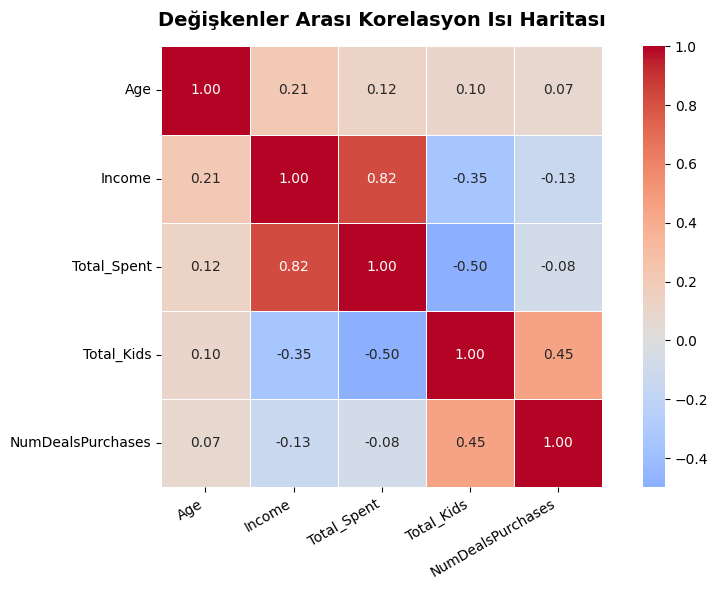

In [5]:
# 1. KORELASYON MATRİSİ
korelasyon_sutunlari = ['Age', 'Income', 'Total_Spent', 'Total_Kids', 'NumDealsPurchases']
korelasyon_matrisi = df[korelasyon_sutunlari].corr()

# 2. KORELASYON ISI HARİTASI
fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    korelasyon_matrisi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Değişkenler Arası Korelasyon Isı Haritası', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

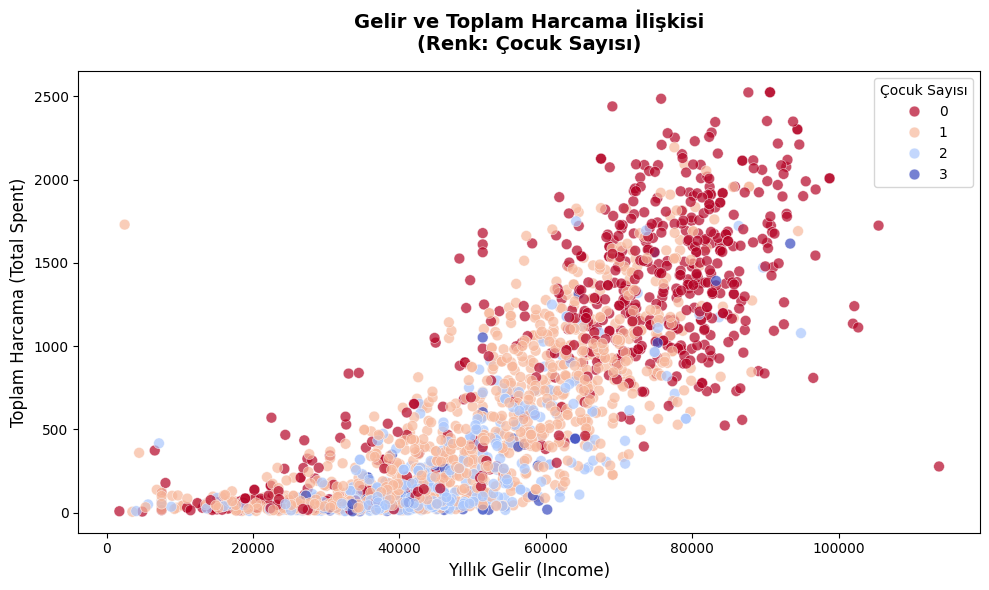

In [6]:
# GELİR vs TOPLAM HARCAMA DAĞILIM GRAFİĞİ
fig, ax = plt.subplots(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spent',
    hue='Total_Kids',
    palette='coolwarm_r',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.4,
    s=60,
    ax=ax
)

ax.set_title('Gelir ve Toplam Harcama İlişkisi\n(Renk: Çocuk Sayısı)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Yıllık Gelir (Income)', fontsize=12)
ax.set_ylabel('Toplam Harcama (Total Spent)', fontsize=12)

ax.get_legend().set_title('Çocuk Sayısı')

plt.tight_layout()
plt.show()

Yaş grubu dağılımı:
Age_Group
Genç (18-35)         476
Orta Yaş (36-50)    1013
İleri Yaş (51+)      740
Name: count, dtype: int64


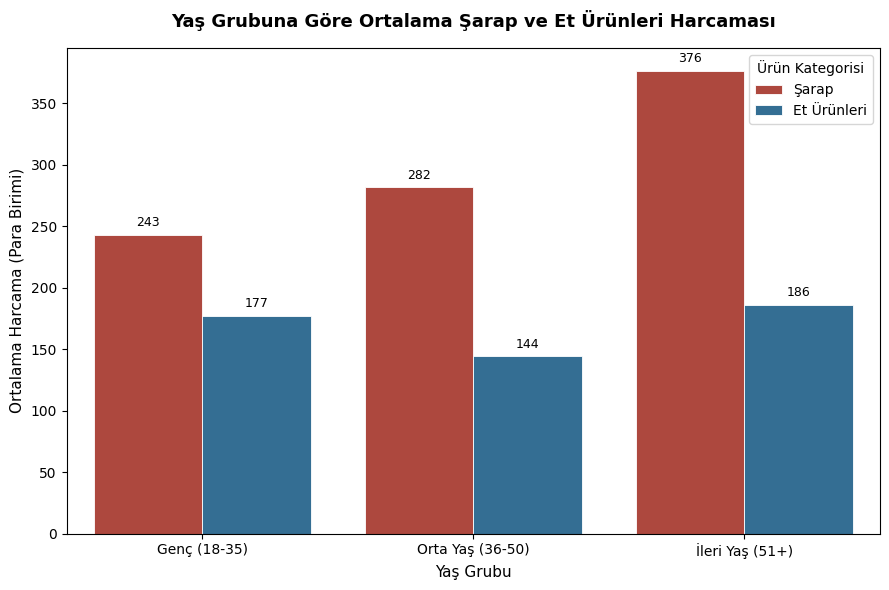

In [7]:
# YAŞ GRUBU OLUŞTURMA
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[18, 36, 51, df['Age'].max() + 1],
    labels=['Genç (18-35)', 'Orta Yaş (36-50)', 'İleri Yaş (51+)'],
    right=False
)

print("Yaş grubu dağılımı:")
print(df['Age_Group'].value_counts().sort_index())

#  GRUP BAZINDA ORTALAMA HARCAMA
harcama_gruplari = (
    df.groupby('Age_Group', observed=True)[['MntWines', 'MntMeatProducts']]
    .mean()
    .reset_index()
)

harcama_long = harcama_gruplari.melt(
    id_vars='Age_Group',
    value_vars=['MntWines', 'MntMeatProducts'],
    var_name='Ürün Kategorisi',
    value_name='Ortalama Harcama'
)

harcama_long['Ürün Kategorisi'] = harcama_long['Ürün Kategorisi'].map({
    'MntWines': 'Şarap',
    'MntMeatProducts': 'Et Ürünleri'
})

#  GROUPED BAR PLOT
fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=harcama_long,
    x='Age_Group',
    y='Ortalama Harcama',
    hue='Ürün Kategorisi',
    palette=['#c0392b', '#2471a3'],
    edgecolor='white',
    linewidth=0.6,
    ax=ax
)

ax.set_title('Yaş Grubuna Göre Ortalama Şarap ve Et Ürünleri Harcaması', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Yaş Grubu', fontsize=11)
ax.set_ylabel('Ortalama Harcama (Para Birimi)', fontsize=11)
ax.legend(title='Ürün Kategorisi', fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=4, fontsize=9)

plt.tight_layout()
plt.show()

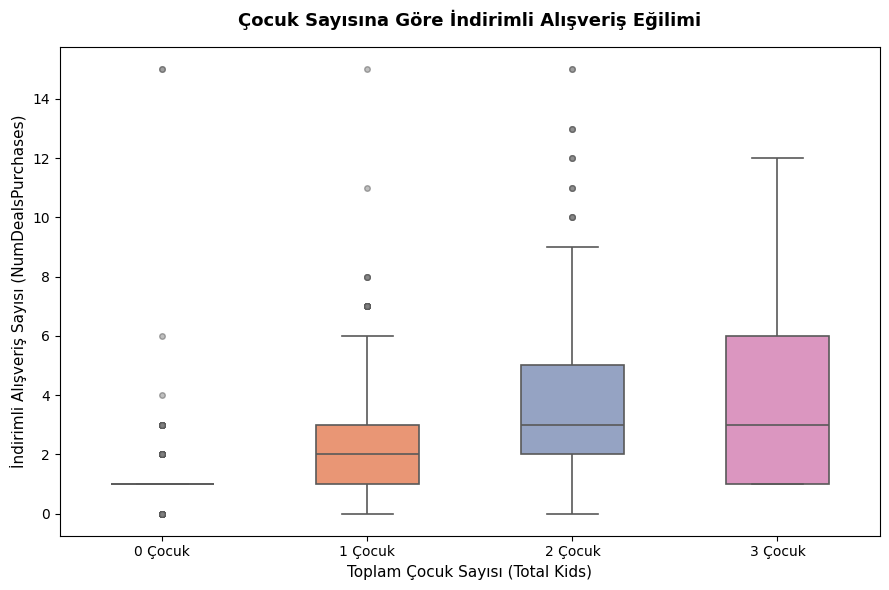

In [8]:
# ÇOCUK SAYISI vs İNDİRİMLİ ALIŞVERİŞ (KUTU GRAFİĞİ)
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Total_Kids',
    y='NumDealsPurchases',
    hue='Total_Kids',
    palette='Set2',
    width=0.5,
    flierprops=dict(
        marker='o',
        markerfacecolor='gray',
        markersize=4,
        alpha=0.5
    ),
    linewidth=1.2,
    legend=False,
    ax=ax
)

ax.set_title('Çocuk Sayısına Göre İndirimli Alışveriş Eğilimi', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Toplam Çocuk Sayısı (Total Kids)', fontsize=11)
ax.set_ylabel('İndirimli Alışveriş Sayısı (NumDealsPurchases)', fontsize=11)

tick_degerleri = sorted(df['Total_Kids'].unique())
ax.set_xticks(range(len(tick_degerleri)))
ax.set_xticklabels([f'{int(v)} Çocuk' for v in tick_degerleri])

plt.tight_layout()
plt.show()

In [9]:
#  MODEL ÖZELLİKLERİNİN SEÇİMİ
X = df[['Age', 'Income', 'Total_Spent']].copy()

print("Model girdisi boyutu:", X.shape)
print("\nÖzellik istatistikleri (ham):")
print(X.describe().round(2))

#  VERİYİ ÖLÇEKLENDİR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  SONUCU TEYİT ET
X_scaled_df = pd.DataFrame(X_scaled, columns=['Age', 'Income', 'Total_Spent'])

print("\nÖlçeklendirilmiş verinin ilk 5 satırı:")
print(X_scaled_df.head().round(4))

print("\nÖlçeklendirilmiş ortalamalar (≈ 0 olmalı):")
print(X_scaled_df.mean().round(6))

print("\nÖlçeklendirilmiş standart sapmalar (≈ 1 olmalı):")
print(X_scaled_df.std().round(4))

Model girdisi boyutu: (2229, 3)

Özellik istatistikleri (ham):
           Age     Income  Total_Spent
count  2229.00    2229.00      2229.00
mean     45.11   51619.50       605.54
std      11.71   20601.22       601.03
min      18.00    1730.00         5.00
25%      37.00   35416.00        69.00
50%      44.00   51381.50       397.00
75%      55.00   68118.00      1044.00
max      74.00  113734.00      2525.00

Ölçeklendirilmiş verinin ilk 5 satırı:
      Age  Income  Total_Spent
0  1.0157  0.3165       1.6832
1  1.2720 -0.2561      -0.9628
2  0.3322  0.9707       0.2837
3 -1.2910 -1.2125      -0.9195
4 -1.0347  0.3240      -0.3054

Ölçeklendirilmiş ortalamalar (≈ 0 olmalı):
Age            0.0
Income         0.0
Total_Spent    0.0
dtype: float64

Ölçeklendirilmiş standart sapmalar (≈ 1 olmalı):
Age            1.0002
Income         1.0002
Total_Spent    1.0002
dtype: float64


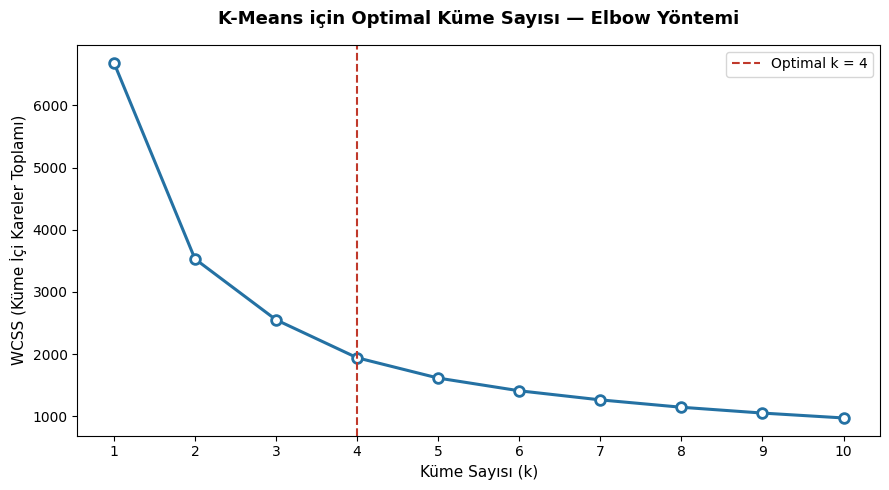

k değeri → WCSS:
  k=1: 6,687.00
  k=2: 3,531.29
  k=3: 2,553.00
  k=4: 1,942.80
  k=5: 1,616.29
  k=6: 1,412.00
  k=7: 1,265.86
  k=8: 1,147.33
  k=9: 1,053.78
  k=10: 975.24


In [11]:
from sklearn.cluster import KMeans

#  WCSS DEĞERLERİNİN HESAPLANMASI
wcss = []
k_araligi = range(1, 11)

for k in k_araligi:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#  ELBOW GRAFİĞİ
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    k_araligi, wcss,
    marker='o',
    markersize=7,
    color='#2471a3',
    linewidth=2.2,
    markerfacecolor='white',
    markeredgewidth=2
)

ax.axvline(x=4, color='#c0392b', linestyle='--', linewidth=1.5, label='Optimal k = 4')

ax.set_title('K-Means için Optimal Küme Sayısı — Elbow Yöntemi', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Küme Sayısı (k)', fontsize=11)
ax.set_ylabel('WCSS (Küme İçi Kareler Toplamı)', fontsize=11)
ax.set_xticks(k_araligi)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("k değeri → WCSS:")
for k, w in zip(k_araligi, wcss):
    print(f"  k={k}: {w:,.2f}")

Model eğitimi tamamlandı.
Final WCSS (Inertia): 1,942.80


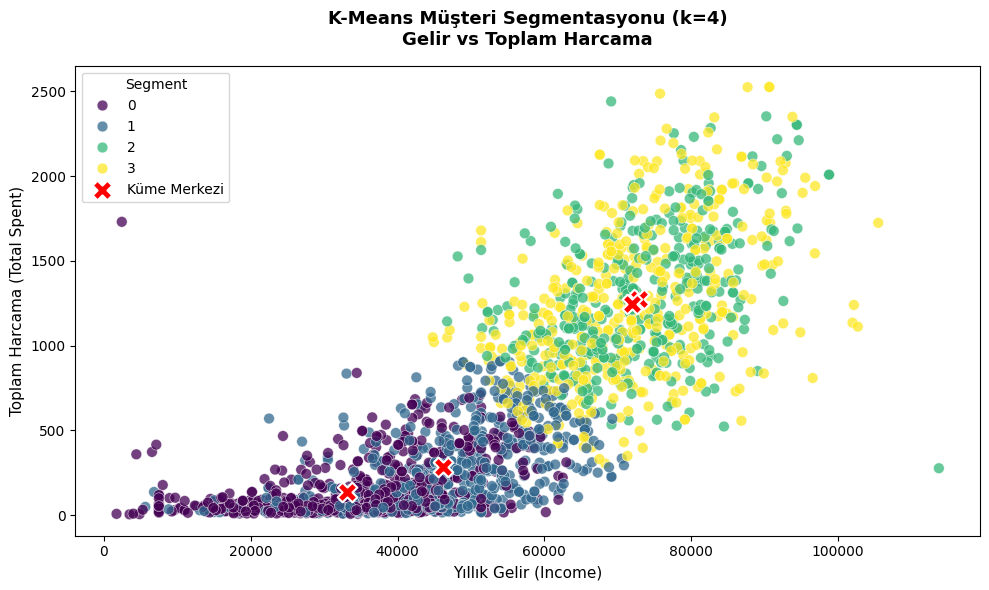


Her segmente atanan müşteri sayısı:
Segment
0    790
1    581
2    392
3    466
Name: count, dtype: int64


In [12]:
#  K-MEANS MODELİNİN KURULMASI
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df['Segment'] = kmeans.fit_predict(X_scaled)

print("Model eğitimi tamamlandı.")
print(f"Final WCSS (Inertia): {kmeans.inertia_:,.2f}")

#  SEGMENT DAĞILIM GRAFİĞİ
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spent',
    hue='Segment',
    palette='viridis',
    alpha=0.75,
    edgecolors='white',
    linewidth=0.4,
    s=60,
    ax=ax
)

# Küme merkezlerini orijinal ölçeğe geri dönüştürerek grafiğe ekle
merkezler_gercek = scaler.inverse_transform(kmeans.cluster_centers_)

ax.scatter(
    merkezler_gercek[:, 1],
    merkezler_gercek[:, 2],
    c='red',
    marker='X',
    s=200,
    linewidths=1.5,
    edgecolors='white',
    zorder=5,
    label='Küme Merkezi'
)

ax.set_title('K-Means Müşteri Segmentasyonu (k=4)\nGelir vs Toplam Harcama', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Yıllık Gelir (Income)', fontsize=11)
ax.set_ylabel('Toplam Harcama (Total Spent)', fontsize=11)
ax.legend(title='Segment', fontsize=10)

plt.tight_layout()
plt.show()

# SEGMENT BAZINDA MÜŞTERİ SAYISI
print("\nHer segmente atanan müşteri sayısı:")
print(df['Segment'].value_counts().sort_index())

In [13]:
#  SEGMENT PROFİLİ TABLOSU
profil_sutunlari = ['Age', 'Income', 'Total_Spent', 'Total_Kids', 'NumDealsPurchases']

segment_profili = (
    df.groupby('Segment')[profil_sutunlari]
    .mean()
    .round(2)
)

segment_profili['Müşteri Sayısı'] = df['Segment'].value_counts().sort_index()

print("Segment Profili (Ortalama Değerler):\n")
print(segment_profili.to_string())

#  SEGMENT İSİMLENDİRME
segment_isimleri = {
    0: 'Düşük Bütçeli Genç Aileler',
    1: 'Orta Bütçeli Olgun Aileler',
    2: 'Yüksek Gelirli Olgunlar (VIP Senior)',
    3: 'Yüksek Gelirli Genç Profesyoneller (VIP Gençler)'
}

df['Segment_Adi'] = df['Segment'].map(segment_isimleri)

print("\nSegment İsim Haritası:")
for k, v in segment_isimleri.items():
    print(f"  Segment {k} → {v}")

#  İSİMLENDİRİLMİŞ ÖZET TABLO
segment_profili.index = segment_profili.index.map(segment_isimleri)

print("\nİsimlendirilmiş Segment Profili:\n")
print(segment_profili.to_string())

Segment Profili (Ortalama Değerler):

           Age    Income  Total_Spent  Total_Kids  NumDealsPurchases  Müşteri Sayısı
Segment                                                                             
0        36.46  33086.22       134.55        1.13               2.33             790
1        55.13  46186.78       283.13        1.34               2.79             581
2        57.52  72936.72      1272.69        0.49               1.97             392
3        36.85  71879.93      1244.76        0.55               2.01             466

Segment İsim Haritası:
  Segment 0 → Düşük Bütçeli Genç Aileler
  Segment 1 → Orta Bütçeli Olgun Aileler
  Segment 2 → Yüksek Gelirli Olgunlar (VIP Senior)
  Segment 3 → Yüksek Gelirli Genç Profesyoneller (VIP Gençler)

İsimlendirilmiş Segment Profili:

                                                    Age    Income  Total_Spent  Total_Kids  NumDealsPurchases  Müşteri Sayısı
Segment                                                                